b)

b)i

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = Path("../data/combined_cycle_power_plant/Folds5x2_pp.xlsx")

df = pd.read_excel(
    data_path,
    sheet_name=0,
    engine="openpyxl"
)

df.columns = df.columns.str.strip()

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:", df.columns.tolist())

display(df.head())

Number of rows: 9568
Number of columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


b) i Answer

The dataset contains 9,568 rows and 5 columns. Each row represents one hourly averaged observation collected from the combined cycle power plant while it was operating at full load.

The first four columns are the predictor variables: AT: ambient temperature. V: exhaust vacuum. AP: ambient pressure. RH: relative humidity. PE is the response variable and represents the net hourly electrical energy output of the power plant.

b) ii 

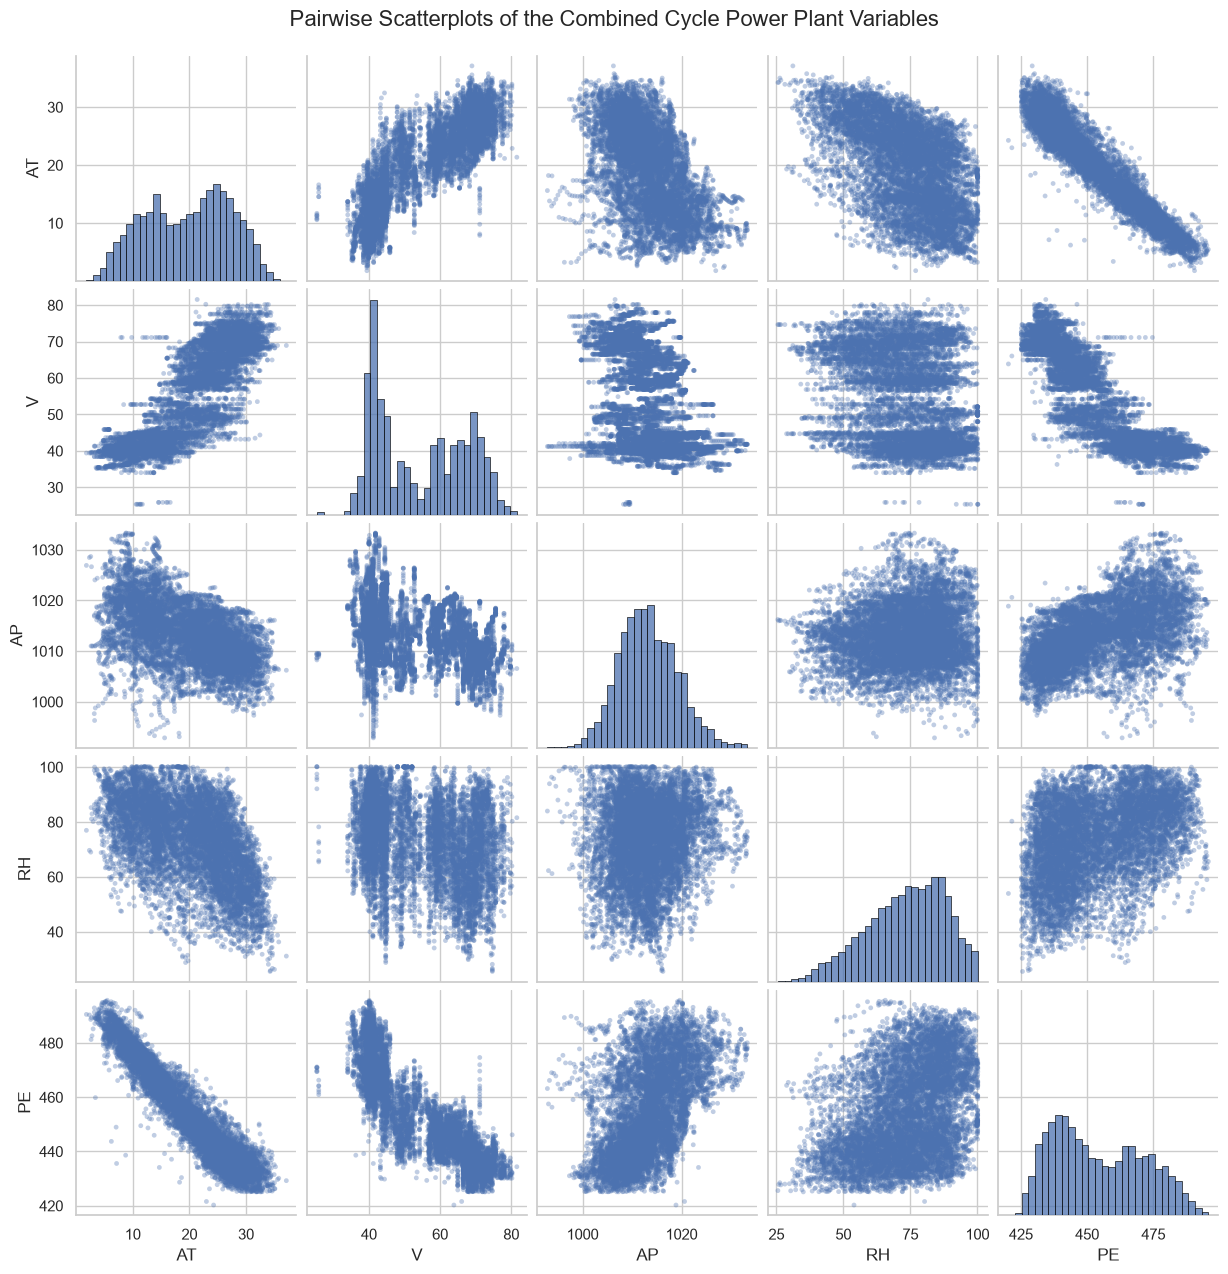

In [4]:
sns.set_theme(style="whitegrid")

pair_plot = sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.35,
        "s": 12,
        "edgecolor": "none"
    },
    diag_kws={
        "bins": 30,
        "edgecolor": "black"
    }
)

pair_plot.fig.suptitle(
    "Pairwise Scatterplots of the Combined Cycle Power Plant Variables",
    y=1.02,
    fontsize=16
)

plt.show()

b) ii Answer

 PE has a strong negative relationship with AT. As ambient temperature increases, the electrical energy output generally decreases. The relationship appears approximately linear, although some variation and slight curvature can be observed.PE also has a strong negative relationship with V. Higher exhaust vacuum values are generally associated with lower electrical energy output. The observations appear in several clusters, so this relationship is less uniformly linear than the relationship between AT and PE.AP has a moderate positive relationship with PE. In general, higher ambient pressure is associated with higher electrical energy output.

b) iii

In [5]:
summary_statistics = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Range": df.max(numeric_only=True) - df.min(numeric_only=True),
    "First Quartile (Q1)": df.quantile(0.25, numeric_only=True),
    "Third Quartile (Q3)": df.quantile(0.75, numeric_only=True),
    "Interquartile Range (IQR)": (
        df.quantile(0.75, numeric_only=True)
        - df.quantile(0.25, numeric_only=True)
    )
})

display(summary_statistics.round(3))

,Mean,Median,Range,First Quartile (Q1),Third Quartile (Q3),Interquartile Range (IQR)
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


c)

In [8]:
import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
results = []

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df["PE"]

    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model

    results.append({
        "Predictor": predictor,
        "Coefficient": model.params[predictor],
        "p-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_regression_results = pd.DataFrame(results)

display(simple_regression_results)

,Predictor,Coefficient,p-value,R-squared
0,AT,-2.171320,0.0,0.898948
1,V,-1.168135,0.0,0.756518
2,AP,1.489872,0.0,0.268769
3,RH,0.455650,0.0,0.151939


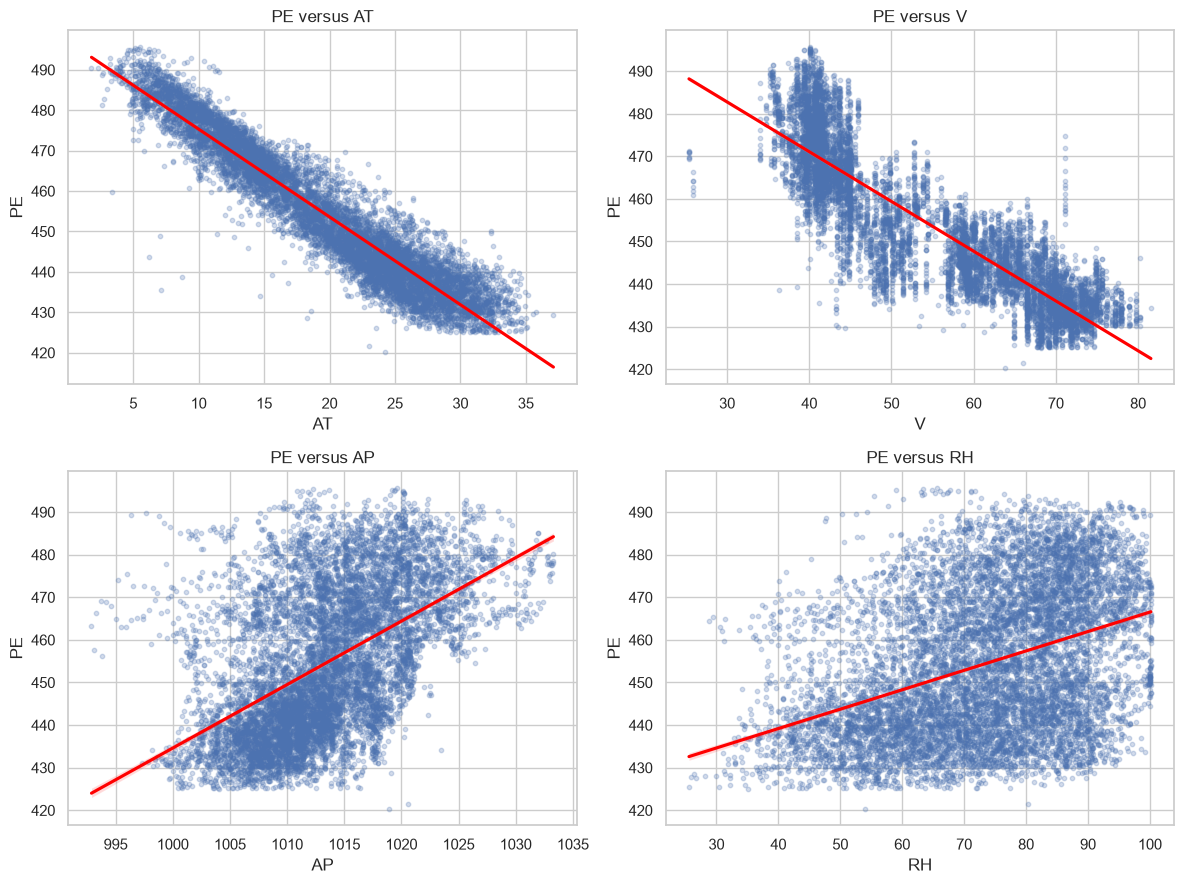

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        ax=ax,
        scatter_kws={"alpha": 0.25, "s": 10},
        line_kws={"color": "red"}
    )

    ax.set_title(f"PE versus {predictor}")

plt.tight_layout()
plt.show()

c) Answer

All four predictors have statistically significant associations with PE because their p-values are approximately zero. AT and V have negative coefficients, while AP and RH have positive coefficients.

AT is the strongest individual predictor, with an R-squared of 0.899, followed by V with an R-squared of 0.757. AP and RH are much weaker predictors, with R-squared values of 0.269 and 0.152, respectively.

The plots show a strong negative relationship between PE and both AT and V, while AP and RH have weaker positive relationships with PE. A few observations appear far from the regression lines, especially in the AT and V models. However, there is no evidence that they are data-entry errors, so I would not remove them.

d)

In [10]:
X = df[["AT", "V", "AP", "RH"]]
X = sm.add_constant(X)
y = df["PE"]

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:41:36   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

d) Answer

The multiple regression model has an R-squared of 0.929, indicating that the four predictors together explain approximately 92.9% of the variation in PE.

AT, V, AP, and RH all have p-values below 0.05. Therefore, we can reject H0: βj = 0 for all four predictors. After controlling for the other predictors, AT, V, and RH have negative coefficients, while AP has a positive coefficient.

e)

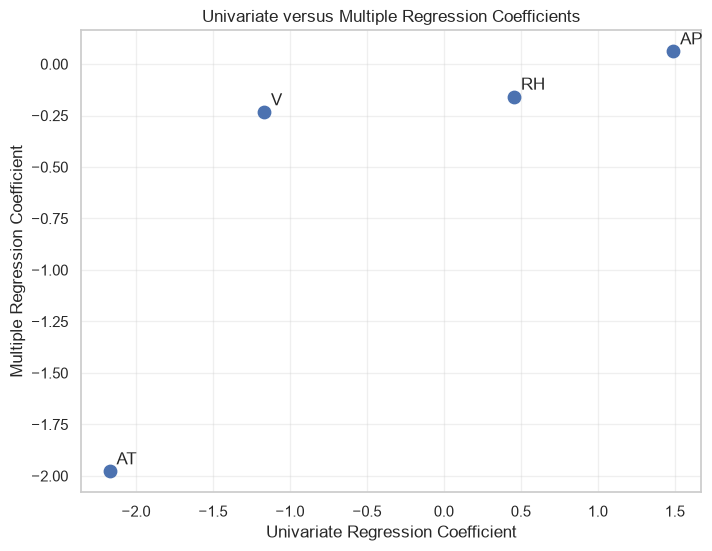

In [11]:
univariate_coefficients = [
    simple_models[predictor].params[predictor]
    for predictor in predictors
]

multiple_coefficients = [
    multiple_model.params[predictor]
    for predictor in predictors
]

plt.figure(figsize=(8, 6))

plt.scatter(
    univariate_coefficients,
    multiple_coefficients,
    s=80
)

for predictor, x, y in zip(
    predictors,
    univariate_coefficients,
    multiple_coefficients
):
    plt.annotate(
        predictor,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Univariate Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Univariate versus Multiple Regression Coefficients")
plt.grid(alpha=0.3)
plt.show()

e) Answer

The coefficients change after including all predictors in one model. AT remains strongly negative, while the coefficients of V and AP become much smaller, and RH changes from positive to negative. This suggests that the predictors are correlated and that the simple regression results are affected by the other predictors.

f)

In [13]:
polynomial_results = []
polynomial_models = {}

for predictor in predictors:
    x = (df[predictor] - df[predictor].mean()) / df[predictor].std()

    X_poly = pd.DataFrame({
        "x": x,
        "x2": x ** 2,
        "x3": x ** 3
    })

    model = sm.OLS(df["PE"], sm.add_constant(X_poly)).fit()
    polynomial_models[predictor] = model

    nonlinear_test = model.f_test("x2 = 0, x3 = 0")

    polynomial_results.append({
        "Predictor": predictor,
        "Nonlinearity p-value": float(nonlinear_test.pvalue)
    })

polynomial_results = pd.DataFrame(polynomial_results)
display(polynomial_results)

,Predictor,Nonlinearity p-value
0,AT,3.478379e-285
1,V,7.040304e-165
2,AP,4.209145e-84
3,RH,3.799622e-05


f) Answer

All four predictors have nonlinearity p-values below 0.05. Therefore, there is significant evidence of nonlinear associations between PE and each of AT, V, AP, and RH.

g)

In [14]:
import statsmodels.formula.api as smf

interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params,
    "p-value": interaction_model.pvalues
})

interaction_results = interaction_results[
    interaction_results.index.str.contains(":")
]

display(interaction_results)

,Coefficient,p-value
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02
AP:RH,-0.001612,3.360557e-02


g) Answer

AT:V, AT:RH, V:AP, and AP:RH are statistically significant because their p-values are below 0.05. AT:AP and V:RH are not statistically significant.

h)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_data, test_data = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

train_mean = train_data[predictors].mean()
train_std = train_data[predictors].std()

train_data = train_data.copy()
test_data = test_data.copy()

train_data[predictors] = (
    train_data[predictors] - train_mean
) / train_std

test_data[predictors] = (
    test_data[predictors] - train_mean
) / train_std

In [17]:
baseline_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_data
).fit()

main_terms = ["AT", "V", "AP", "RH"]

higher_order_terms = [
    "AT:V", "AT:AP", "AT:RH",
    "V:AP", "V:RH", "AP:RH",
    "I(AT ** 2)", "I(V ** 2)",
    "I(AP ** 2)", "I(RH ** 2)"
]

selected_terms = higher_order_terms.copy()

while True:
    formula = "PE ~ " + " + ".join(main_terms + selected_terms)
    enhanced_model = smf.ols(formula, data=train_data).fit()

    nonsignificant = enhanced_model.pvalues[
        selected_terms
    ][enhanced_model.pvalues[selected_terms] > 0.05]

    if nonsignificant.empty:
        break

    selected_terms.remove(nonsignificant.idxmax())

mse_results = pd.DataFrame({
    "Model": ["Basic Linear Model", "Reduced Enhanced Model"],
    "Train MSE": [
        mean_squared_error(
            train_data["PE"],
            baseline_model.predict(train_data)
        ),
        mean_squared_error(
            train_data["PE"],
            enhanced_model.predict(train_data)
        )
    ],
    "Test MSE": [
        mean_squared_error(
            test_data["PE"],
            baseline_model.predict(test_data)
        ),
        mean_squared_error(
            test_data["PE"],
            enhanced_model.predict(test_data)
        )
    ]
})

print("Retained higher-order terms:", selected_terms)
display(mse_results)

Retained higher-order terms: ['AT:V', 'AT:AP', 'AT:RH', 'AP:RH', 'I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)']


,Model,Train MSE,Test MSE
0,Basic Linear Model,20.580840,21.239857
1,Reduced Enhanced Model,17.890843,18.660040


h) Answer

The reduced enhanced model retained AT:V, AT:AP, AT:RH, AP:RH, AT², AP², and RH². It improved the train MSE from 20.581 to 17.891 and the test MSE from 21.240 to 18.660, indicating better predictive performance.

i)

,Features,Best k,Train MSE,Test MSE
0,Raw,5,10.600769,15.726820
1,Normalized,4,8.454348,14.291333


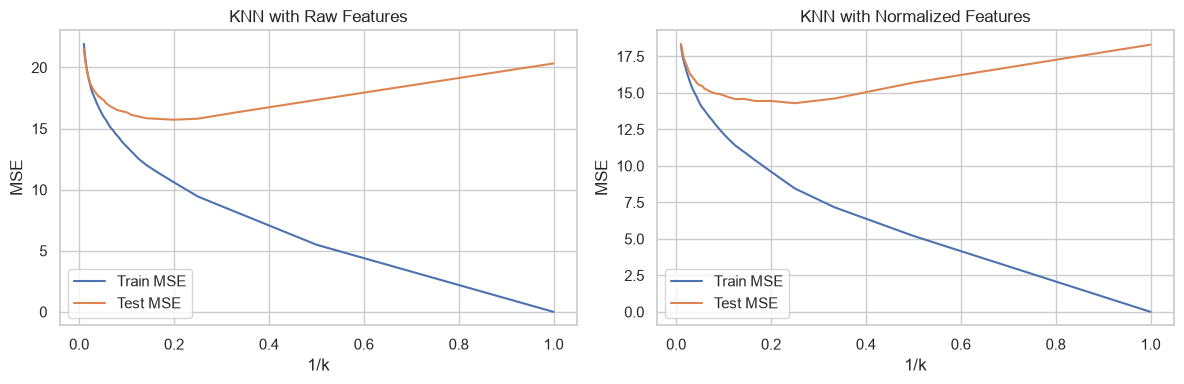

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

k_values = np.arange(1, 101)

def calculate_knn_errors(X_train_data, X_test_data):
    train_errors = []
    test_errors = []

    for k in k_values:
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_train_data, y_train)

        train_errors.append(
            mean_squared_error(y_train, model.predict(X_train_data))
        )
        test_errors.append(
            mean_squared_error(y_test, model.predict(X_test_data))
        )

    return np.array(train_errors), np.array(test_errors)


raw_train_errors, raw_test_errors = calculate_knn_errors(
    X_train, X_test
)

normalized_train_errors, normalized_test_errors = calculate_knn_errors(
    X_train_normalized, X_test_normalized
)

best_raw_index = np.argmin(raw_test_errors)
best_normalized_index = np.argmin(normalized_test_errors)

best_raw_k = k_values[best_raw_index]
best_normalized_k = k_values[best_normalized_index]

knn_summary = pd.DataFrame({
    "Features": ["Raw", "Normalized"],
    "Best k": [best_raw_k, best_normalized_k],
    "Train MSE": [
        raw_train_errors[best_raw_index],
        normalized_train_errors[best_normalized_index]
    ],
    "Test MSE": [
        raw_test_errors[best_raw_index],
        normalized_test_errors[best_normalized_index]
    ]
})

display(knn_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(1 / k_values, raw_train_errors, label="Train MSE")
axes[0].plot(1 / k_values, raw_test_errors, label="Test MSE")
axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(1 / k_values, normalized_train_errors, label="Train MSE")
axes[1].plot(1 / k_values, normalized_test_errors, label="Test MSE")
axes[1].set_title("KNN with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

i) Answer

For the raw features, the best k is 5, with a test MSE of 15.727. For the normalized features, the best k is 4, with a test MSE of 14.291. Therefore, normalization improves the performance of KNN regression.

j)

In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Reduced Enhanced Linear Model",
        "KNN with Raw Features",
        "KNN with Normalized Features"
    ],
    "Best k": [
        np.nan,
        best_raw_k,
        best_normalized_k
    ],
    "Train MSE": [
        17.890843,
        raw_train_errors[best_raw_index],
        normalized_train_errors[best_normalized_index]
    ],
    "Test MSE": [
        18.660040,
        raw_test_errors[best_raw_index],
        normalized_test_errors[best_normalized_index]
    ]
})

display(comparison)

,Model,Best k,Train MSE,Test MSE
0,Reduced Enhanced Linear Model,NaN,17.890843,18.660040
1,KNN with Raw Features,5.0,10.600769,15.726820
2,KNN with Normalized Features,4.0,8.454348,14.291333


j) Answer

Both KNN models outperform the reduced enhanced linear model, whose test MSE is 18.660. The normalized KNN model performs best, with the lowest test MSE of 14.291.